In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
vocab_size = 10000  # top 10k words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 25000
Test samples: 25000


In [5]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [6]:
model = Sequential([
    Input(shape=(max_len,)),
    
    Embedding(vocab_size, 64),
    
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),  # 👈 add this
    
    Dense(32, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')
])

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 91s 545ms/step - accuracy: 0.7130 - loss: 0.5497 - val_accuracy: 0.7918 - val_loss: 0.4446
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 536ms/step - accuracy: 0.8607 - loss: 0.3482 - val_accuracy: 0.8588 - val_loss: 0.3502
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 85s 544ms/step - accuracy: 0.8816 - loss: 0.3017 - val_accuracy: 0.8576 - val_loss: 0.3422
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 535ms/step - accuracy: 0.8891 - loss: 0.2823 - val_accuracy: 0.8000 - val_loss: 0.4305
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 85s 540ms/step - accuracy: 0.9145 - loss: 0.2315 - val_accuracy: 0.8460 - val_loss: 0.3891


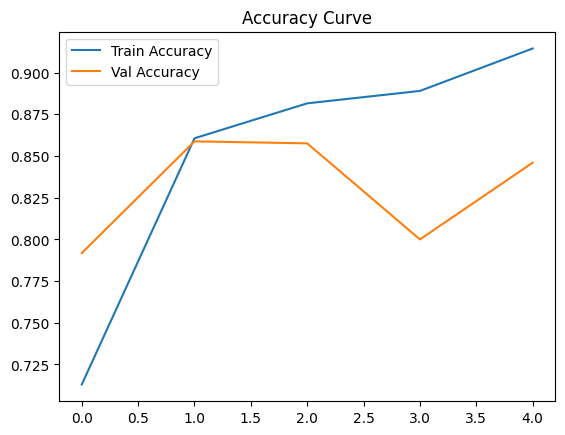

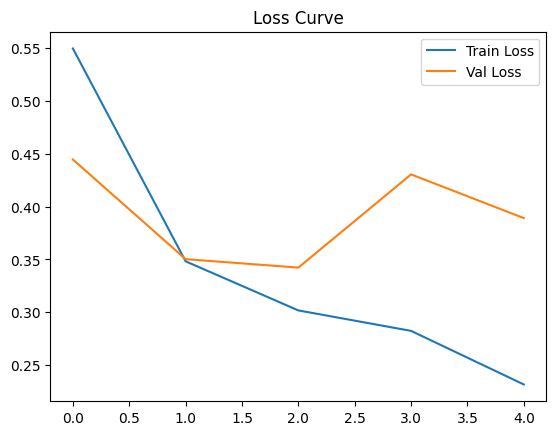

In [10]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8482 - loss: 0.3895
Test Loss: 0.3894578218460083
Test Accuracy: 0.8481600284576416


In [12]:
predictions = model.predict(X_test)

for i in range(5):
    sentiment = "Positive 😊" if predictions[i][0] > 0.5 else "Negative 😡"
    print(f"Prediction: {predictions[i][0]:.2f} → {sentiment}, Actual: {y_test[i]}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step
Prediction: 0.21 → Negative 😡, Actual: 0
Prediction: 1.00 → Positive 😊, Actual: 1
Prediction: 0.96 → Positive 😊, Actual: 1
Prediction: 0.39 → Negative 😡, Actual: 0
Prediction: 1.00 → Positive 😊, Actual: 1


In [13]:
word_index = imdb.get_word_index()
reverse_index = {v: k for k, v in word_index.items()}

def decode_review(encoded_review):
    return " ".join([reverse_index.get(i-3, "?") for i in encoded_review])

print(decode_review(X_train[0]))

and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you think the whole story was so lovely because it was true and was someone's life after all that was shared with us all
